# 2. Downlink power optimisation discussion

This notebook starts from the cleaned single-user solver and asks a different question from the candidate-space notebook. Instead of asking what the solver can generate, it asks how the optimum changes when the user demand becomes harder.

The notebook answers that question through two linked studies built on the same single-user engine: a fixed-distance throughput study at a 400 m link distance, and a fixed-throughput distance study from 50 m to 500 m with a 250 Mbps requirement. The notebook is therefore not a verification log. It is a reader-facing discussion of when the optimal operating point changes, which PA remains competitive, and which resource-allocation choices move with the demand.


## 1. Setup and notebook scope

The notebook keeps the same plain style as the earlier candidate-space walkthrough. The first step is to define the two study cases, prepare one reference scenario, and keep the display helpers out of the main notebook flow.

Only the public single-user interfaces are used in the visible notebook cells. The helper module only supports presentation, frontier summarisation, and export.


In [12]:
import numpy as np
import pandas as pd
from IPython.display import display

%matplotlib inline

from helpers.power_optimisation_helpers import (
    PA_LABEL_MAP,
    PROJECT_ROOT,
    build_candidate_space_view,
    build_objective_output_summary,
    build_physical_energy_summary,
    build_regime_summary,
    build_single_user_scenario,
    enumerate_active_candidates,
    plot_grouped_frontier_figure,
    prepare_frontier_plotting,
    run_distance_study,
    run_rate_study,
    search_candidates,
    select_best_candidate_row,
)


## 2. Study definitions

The notebook compares two related studies that share the same radio assumptions and the same solver-owned search catalog.

A low-demand reference scenario is also prepared here. It is not a stand-in for the full study. Its role is only to expose the prepared solver context and the common search-space envelope that both studies inherit.

The next table lists the two studies, their fixed quantity, and their sampling.


In [13]:
# Define the two study cases and prepare one low-demand reference point.
rate_required_targets_bps = np.linspace(1e6, 300e6, 100)
distance_values_m = np.arange(50.0, 500.0 + 25.0, 25.0).tolist()

rate_study_config = {
    "study_name": "rate",
    "distance_m": 400.0,
    "rate_targets_bps": rate_required_targets_bps.tolist(),
}

distance_study_config = {
    "study_name": "distance",
    "distance_values_m": distance_values_m,
    "rate_target_bps": 250e6,
}

reference_scenario = build_single_user_scenario(
    distance_m=float(rate_study_config["distance_m"]),
    required_rate_bps=float(np.min(rate_required_targets_bps)),
)
reference_candidate_space_view = build_candidate_space_view(reference_scenario.context).copy()
reference_active_candidate_table = enumerate_active_candidates(reference_scenario.context).copy()
reference_active_candidate_table["pa_name"] = reference_active_candidate_table["pa_id"].map(
    lambda pa_id: PA_LABEL_MAP[int(pa_id)]
)
reference_rate_feasible_candidate_table = search_candidates(
    reference_scenario.context,
    required_rate_bps=float(reference_scenario.request.required_rate_bps),
).copy()
reference_rate_feasible_candidate_table["pa_name"] = reference_rate_feasible_candidate_table["pa_id"].map(
    lambda pa_id: PA_LABEL_MAP[int(pa_id)]
)
reference_solver_winner = select_best_candidate_row(reference_rate_feasible_candidate_table)
reference_candidate_space_row = reference_candidate_space_view.iloc[0]

study_definition_view = pd.DataFrame(
    [
        {
            "study": "Fixed-distance throughput study",
            "varied quantity": "Required throughput",
            "fixed quantity": f"Distance = {float(rate_study_config['distance_m']):.0f} m",
            "domain": (
                f"{float(np.min(rate_required_targets_bps)) / 1e6:.0f} to "
                f"{float(np.max(rate_required_targets_bps)) / 1e6:.0f} Mbps"
            ),
            "sampling": (
                f"{len(rate_required_targets_bps)} points, "
                f"step {float(rate_required_targets_bps[1] - rate_required_targets_bps[0]) / 1e6:.1f} Mbps"
            ),
        },
        {
            "study": "Fixed-throughput distance study",
            "varied quantity": "User distance",
            "fixed quantity": f"Required throughput = {float(distance_study_config['rate_target_bps']) / 1e6:.0f} Mbps",
            "domain": (
                f"{float(min(distance_values_m)):.0f} to "
                f"{float(max(distance_values_m)):.0f} m"
            ),
            "sampling": (
                f"{len(distance_values_m)} points, "
                f"step {float(distance_values_m[1] - distance_values_m[0]):.0f} m"
            ),
        },
    ]
)

display(study_definition_view)


,study,varied quantity,fixed quantity,domain,sampling
0,Fixed-distance throughput study,Required throughput,Distance = 400 m,1 to 300 Mbps,"100 points, step 3.0 Mbps"
1,Fixed-throughput distance study,User distance,Required throughput = 250 Mbps,50 to 500 m,"19 points, step 25 m"


## 3. Shared scenario context

Before running the two studies, it helps to make the common solver context visible once. The next outputs show a one-row reference-case summary and a compact view of the discrete search domain.

That gives the later plots a clear frame of reference. When the winning configuration changes, it is changing inside this fixed prepared catalog.


In [14]:
# Show the shared reference case and the search domain inherited by both studies.
reference_case_view = pd.DataFrame(
    [
        {
            "reference distance (m)": float(reference_scenario.request.distance_m),
            "reference required rate (Mbps)": float(reference_scenario.request.required_rate_bps) / 1e6,
            "reference path loss (dB)": float(reference_scenario.context.deployment.path_loss_db),
            "frame slots": int(reference_scenario.context.deployment.n_slots_win),
            "PA models": len(reference_scenario.context.pa_catalog),
            "active candidates": len(reference_active_candidate_table),
            "rate-feasible candidates": len(reference_rate_feasible_candidate_table),
        }
    ]
)

search_domain_view = pd.DataFrame(
    [
        {
            "bandwidth options (MHz)": ", ".join(
                f"{float(value) / 1e6:.0f}" for value in reference_candidate_space_row["bandwidth_options_hz"]
            ),
            "layer domain": (
                f"{int(reference_candidate_space_row['layer_domain'][0])} to "
                f"{int(reference_candidate_space_row['layer_domain'][1])}"
            ),
            "MCS domain": (
                f"{int(reference_candidate_space_row['mcs_domain'][0])} to "
                f"{int(reference_candidate_space_row['mcs_domain'][1])}"
            ),
            "slot domain": (
                f"{int(reference_candidate_space_row['slot_domain'][0])} to "
                f"{int(reference_candidate_space_row['slot_domain'][1])}"
            ),
            "PRB step": int(reference_candidate_space_row["prb_step"]),
            "raw candidates per scenario": int(reference_candidate_space_row["raw_candidate_count_total"]),
        }
    ]
)

display(reference_case_view)
display(search_domain_view)

,reference distance (m),reference required rate (Mbps),reference path loss (dB),frame slots,PA models,active candidates,rate-feasible candidates
0,400.0,1.0,129.844828,20,2,259940,241408


,bandwidth options (MHz),layer domain,MCS domain,slot domain,PRB step,raw candidates per scenario
0,"50, 100",1 to 4,0 to 28,1 to 20,5,389760


## 4. Run the two frontier studies

The next cell executes both studies through the single-user solver interface. Each scenario builds one prepared context and then reuses the solver-owned rate-feasible candidate table across the requested target-rate cuts.

The two output tables serve different roles. The first reports the search volume behind each study. The second reports the size and coverage of the resulting frontier tables that will be used in the discussion section.


In [15]:
# Run both studies and collect the frontier tables that will be plotted later.
rate_study = run_rate_study(
    distance_m=float(rate_study_config["distance_m"]),
    rate_targets_bps=rate_study_config["rate_targets_bps"],
)
distance_study = run_distance_study(
    distance_values_m=distance_study_config["distance_values_m"],
    required_rate_bps=float(distance_study_config["rate_target_bps"]),
)

rate_frontier_table = rate_study.frontier_table.copy()
distance_frontier_table = distance_study.frontier_table.copy()
rate_explanatory_configs = rate_study.explanatory_configs.copy()
distance_explanatory_configs = distance_study.explanatory_configs.copy()

n_pa_models = len(reference_candidate_space_row["pa_labels"])

search_volume_view = pd.DataFrame(
    [
        {
            "study": "Fixed-distance throughput study",
            "scenario points": 1,
            "PA models": n_pa_models,
            "raw candidates per scenario": int(reference_candidate_space_row["raw_candidate_count_total"]),
            "raw candidates across study": int(rate_study.candidate_space_view.iloc[0]["raw_candidate_count_across_scenarios"]),
            "active feasible rows / scenario": (
                f"{min(rate_study.active_candidate_counts):,} to "
                f"{max(rate_study.active_candidate_counts):,}"
            ),
            "per-PA raw counts": ", ".join(
                f"{label}: {int(count):,}"
                for label, count in rate_study.candidate_space_view.iloc[0]["raw_candidate_count_per_pa"]
            ),
        },
        {
            "study": "Fixed-throughput distance study",
            "scenario points": len(distance_study_config["distance_values_m"]),
            "PA models": n_pa_models,
            "raw candidates per scenario": int(reference_candidate_space_row["raw_candidate_count_total"]),
            "raw candidates across study": int(distance_study.candidate_space_view.iloc[0]["raw_candidate_count_across_scenarios"]),
            "active feasible rows / scenario": (
                f"{min(distance_study.active_candidate_counts):,} to "
                f"{max(distance_study.active_candidate_counts):,}"
            ),
            "per-PA raw counts": ", ".join(
                f"{label}: {int(count):,}"
                for label, count in distance_study.candidate_space_view.iloc[0]["raw_candidate_count_per_pa"]
            ),
        },
    ]
)

frontier_coverage_view = pd.DataFrame(
    [
        {
            "study": "Fixed-distance throughput study",
            "scenario": "Required throughput at fixed distance",
            "axis": "Required throughput (Mbps)",
            "frontier rows": int(len(rate_frontier_table)),
            "explanatory rows": int(len(rate_explanatory_configs)),
            "PA labels": ", ".join(str(label) for label in rate_frontier_table["pa_name"].drop_duplicates().tolist()),
            "x-domain": (
                f"{float(rate_frontier_table['rate_target_bps'].min()) / 1e6:.0f} to "
                f"{float(rate_frontier_table['rate_target_bps'].max()) / 1e6:.0f} Mbps"
            ),
        },
        {
            "study": "Fixed-throughput distance study",
            "scenario": "User distance at fixed throughput",
            "axis": "User distance (m)",
            "frontier rows": int(len(distance_frontier_table)),
            "explanatory rows": int(len(distance_explanatory_configs)),
            "PA labels": ", ".join(
                str(label) for label in distance_frontier_table["pa_name"].drop_duplicates().tolist()
            ),
            "x-domain": (
                f"{float(distance_frontier_table['distance_m'].min()):.0f} to "
                f"{float(distance_frontier_table['distance_m'].max()):.0f} m"
            ),
        },
    ]
)

display(search_volume_view)
display(frontier_coverage_view)


,study,scenario points,PA models,raw candidates per scenario,raw candidates across study,active feasible rows / scenario,per-PA raw counts
0,Fixed-distance throughput study,1,2,389760,389760,"241,408 to 241,408","8W PA: 194,880, 4W PA: 194,880"
1,Fixed-throughput distance study,19,2,389760,7405440,"0 to 23,980","8W PA: 194,880, 4W PA: 194,880"


,study,scenario,axis,frontier rows,explanatory rows,PA labels,x-domain
0,Fixed-distance throughput study,Required throughput at fixed distance,Required throughput (Mbps),152,453,"Bae et al. NR, QPA9942",1 to 300 Mbps
1,Fixed-throughput distance study,User distance at fixed throughput,User distance (m),28,84,"Bae et al. NR, QPA9942",50 to 450 m


## 5. Solver interface snapshot

The dedicated PA walkthrough has been removed from this notebook. In its place, the next tables make the solver handoff explicit: one table names the public single-user solver interfaces used here, and the other shows what those interfaces return for the low-demand reference point.

That keeps this notebook focused on optimisation behaviour while still documenting how the cleaned solver module is used in the study flow.


In [16]:
# Record the public solver interfaces used in this notebook and the reference winner they produce.
solver_interface_view = pd.DataFrame(
    [
        {
            "interface": "prepare_single_user_problem(request, model_inputs, search_shape, pa_catalog)",
            "role in this notebook": "Build one reusable single-user solver context for each deployment scenario.",
            "returns": "PreparedSingleUserContext",
        },
        {
            "interface": "enumerate_active_candidates(context)",
            "role in this notebook": "Expose the full active candidate cloud for the low-demand reference scenario.",
            "returns": "Active candidate table",
        },
        {
            "interface": "search_candidates(context, required_rate_bps)",
            "role in this notebook": "Build the rate-feasible table used for every frontier cut.",
            "returns": "Rate-feasible candidate table",
        },
    ]
)

reference_solver_summary_view = pd.DataFrame(
    [
        {
            "reference point": (
                f"{float(reference_scenario.request.distance_m):.0f} m / "
                f"{float(reference_scenario.request.required_rate_bps) / 1e6:.0f} Mbps"
            ),
            "active candidates": len(reference_active_candidate_table),
            "rate-feasible candidates": len(reference_rate_feasible_candidate_table),
            "winning PA": PA_LABEL_MAP[int(reference_solver_winner["pa_id"])],
            "winning bandwidth (MHz)": float(reference_solver_winner["bandwidth_hz"]) / 1e6,
            "winning PRBs": int(reference_solver_winner["n_prb"]),
            "winning slots": int(reference_solver_winner["n_slots_on"]),
            "winning layers": int(reference_solver_winner["layers"]),
            "winning MCS": int(reference_solver_winner["mcs"]),
        }
    ]
)

display(solver_interface_view)
display(reference_solver_summary_view)


,interface,role in this notebook,returns
0,"prepare_single_user_problem(request, model_inp...",Build one reusable single-user solver context ...,PreparedSingleUserContext
1,enumerate_active_candidates(context),Expose the full active candidate cloud for the...,Active candidate table
2,"search_candidates(context, required_rate_bps)",Build the rate-feasible table used for every f...,Rate-feasible candidate table


,reference point,active candidates,rate-feasible candidates,winning PA,winning bandwidth (MHz),winning PRBs,winning slots,winning layers,winning MCS
0,400 m / 1 Mbps,259940,241408,QPA9942,100.0,216,1,1,3


## 6. Frontier plots

This section develops the frontier in four passes. Each figure shows the fixed-distance throughput study and the fixed-throughput distance study together so that the same optimisation logic can be read under two different demand changes.

The next cell only prepares the shared plotting context. The figures then follow in an order that moves from the objective itself, to the chosen PHY structure, and then to the physical burden behind those choices.


In [17]:
# Build the shared plotting context once so that the later figure cells stay small.
plot_context = prepare_frontier_plotting(
    reference_candidate_space_view=reference_candidate_space_view,
    rate_study_config=rate_study_config,
    distance_study_config=distance_study_config,
    rate_frontier_table=rate_frontier_table,
    distance_frontier_table=distance_frontier_table,
)


### 6.1 Frame-averaged PA input power and PA output power

This first figure sets up the main observation of the section. The left-hand panels show the optimisation objective itself, namely frame-averaged total PA DC input power. The right-hand panels show the corresponding total PA output power for the same frontier rows.

These two columns should be read together. The aim is to show that the optimal PA DC power rises with demand in both studies, but it does not rise in simple proportion to the radiated output power. That gap signals that the optimiser is changing *how* the user is served, not only *how hard* the transmitter is driven.


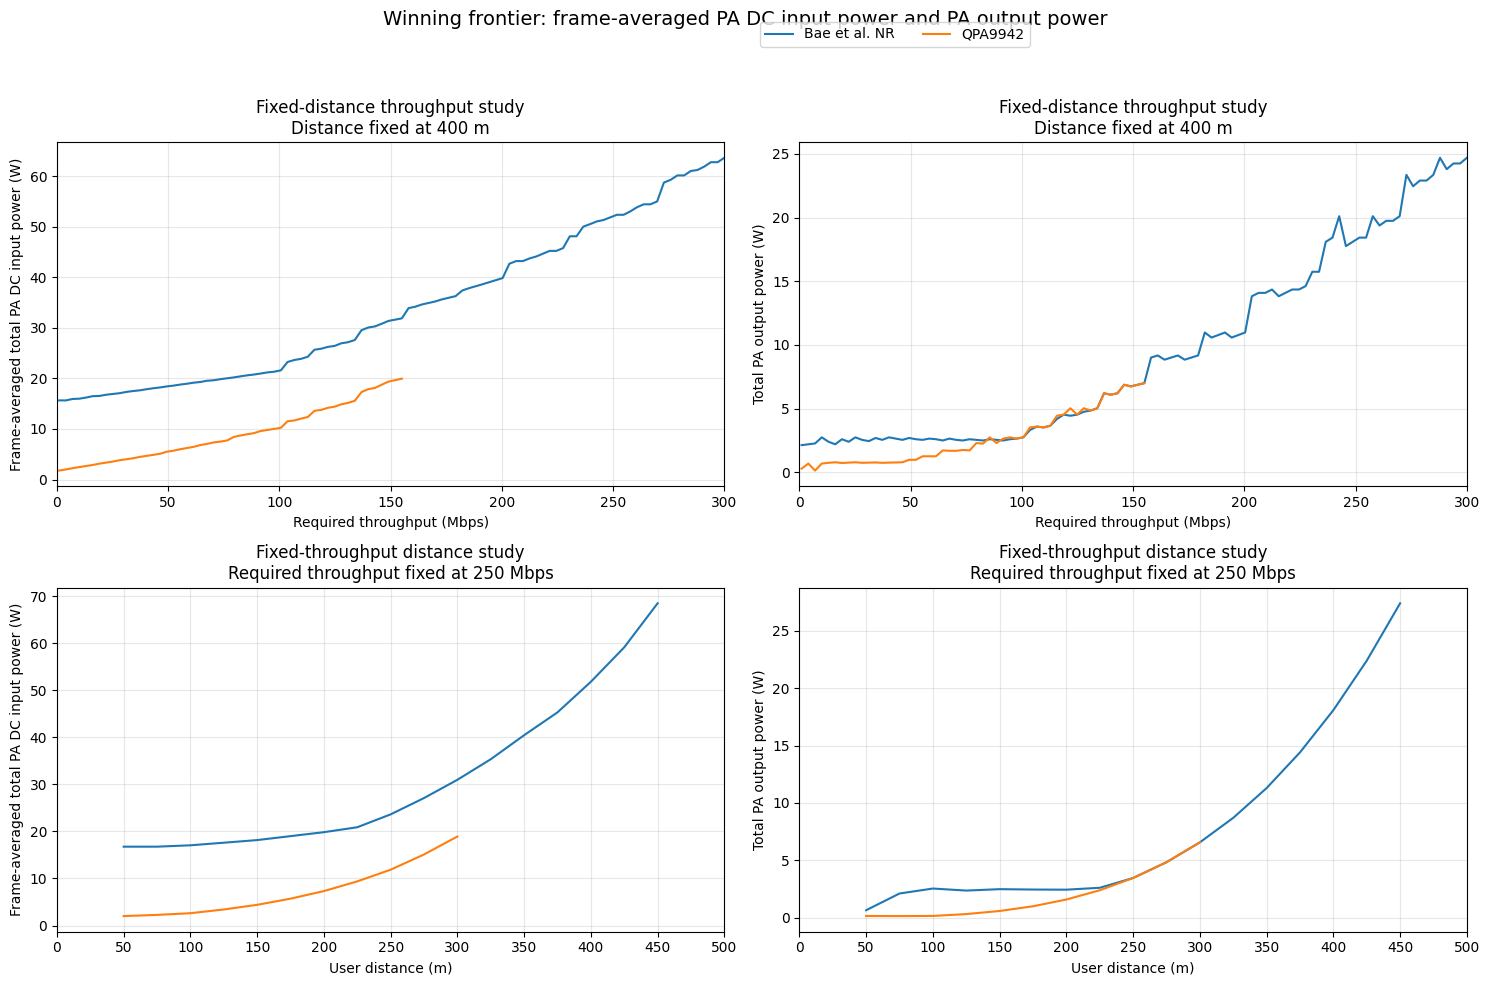

,scenario,start point,end point,winner changes,PA DC growth x,PA output growth x
0,Fixed-distance throughput study,1.0 Mbps,300.0 Mbps,1,35.962498,85.995460
1,Fixed-throughput distance study,50 m,450 m,1,34.176638,206.000467


In [18]:
# Compare the optimisation objective with the corresponding PA output power.
fig_objective_vs_output = plot_grouped_frontier_figure(
    plot_context,
    metric_keys=["p_dc_avg_total_w", "p_out_total_w"],
    figure_title="Winning frontier: frame-averaged PA DC input power and PA output power",
)
objective_output_summary = build_objective_output_summary(plot_context)
display(objective_output_summary)


The summary table under the figure is a compact numerical version of the same point. For each scenario it reports the start and end of the winning frontier and compares how much the objective grows relative to total output power. If those growth factors differ, the optimum is being shaped by resource-allocation choices and PA behaviour, not only by required radiated power.


### 6.2 Spatial layers and modulation and coding selection

The next figure begins to explain the earlier gap. These plots show the chosen number of spatial layers and the selected MCS index along the frontier for both studies.

This is where the notebook should make it clear that the optimiser does not always chase a more aggressive coding point. In some parts of the study it backs off on MCS and compensates with more structural resource use because that combination gives a lower frame-averaged PA DC cost.


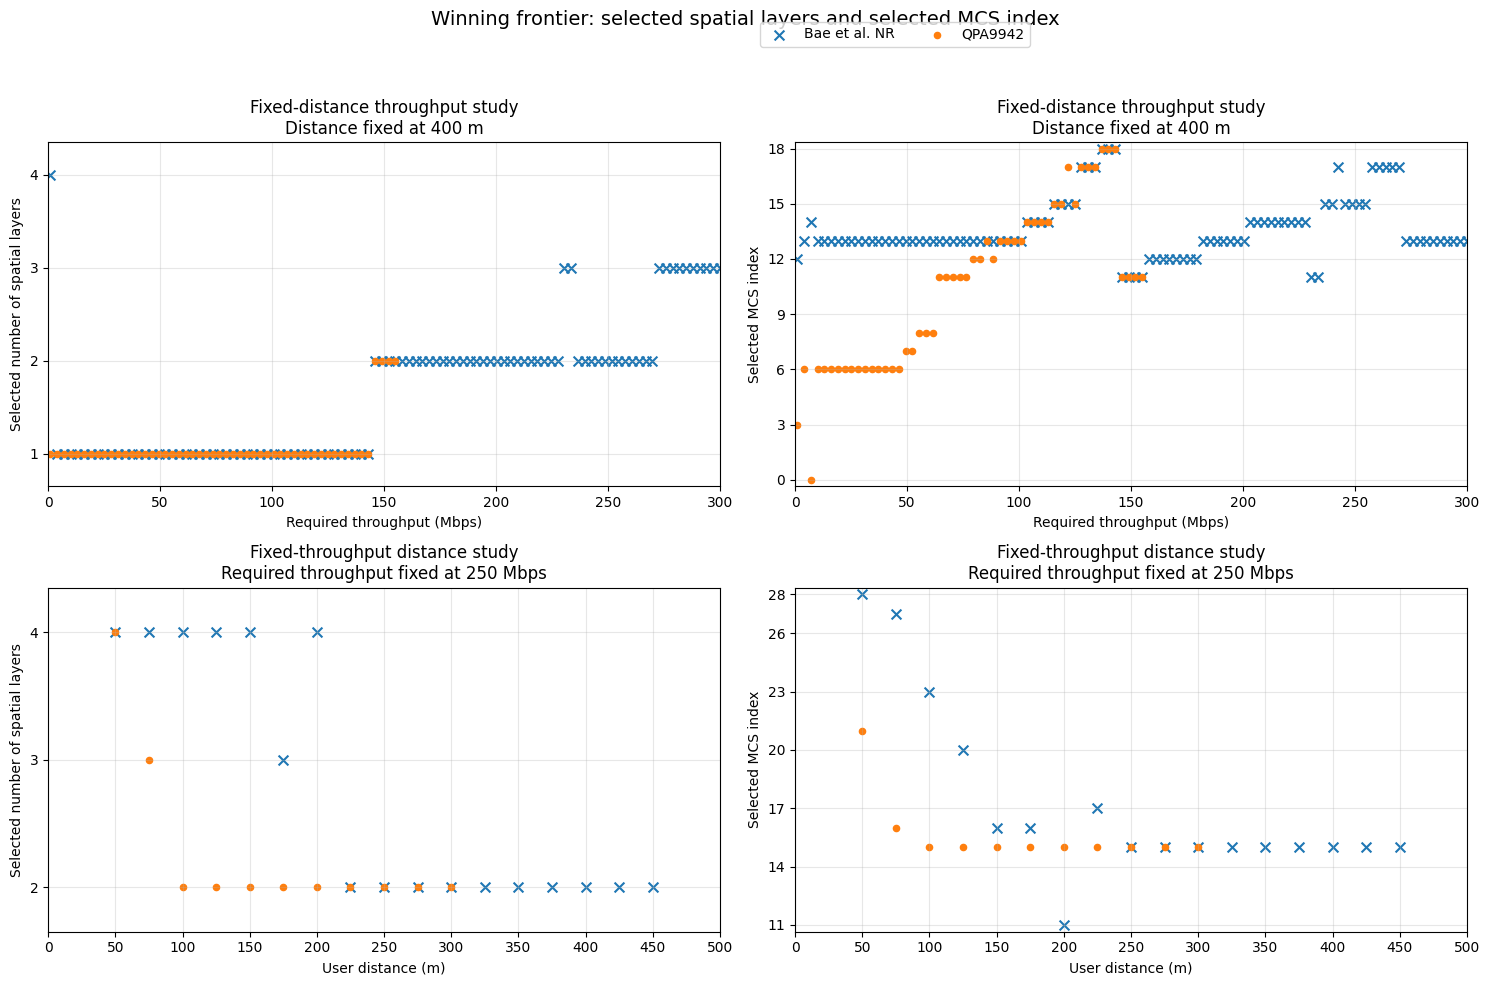

,scenario,at,winner PA,Selected number of spatial layers,Selected MCS index
0,Fixed-distance throughput study,4.0 Mbps,QPA9942,1,6
1,Fixed-distance throughput study,7.0 Mbps,QPA9942,1,0
2,Fixed-distance throughput study,10.1 Mbps,QPA9942,1,6
3,Fixed-distance throughput study,49.3 Mbps,QPA9942,1,7
4,Fixed-distance throughput study,55.4 Mbps,QPA9942,1,8
5,Fixed-distance throughput study,64.4 Mbps,QPA9942,1,11
6,Fixed-throughput distance study,75 m,QPA9942,3,16
7,Fixed-throughput distance study,100 m,QPA9942,2,15


In [19]:
# Show how the winning frontier changes its layer count and coding choice.
fig_spatial_coding = plot_grouped_frontier_figure(
    plot_context,
    metric_keys=["layers", "mcs"],
    figure_title="Winning frontier: selected spatial layers and selected MCS index",
)
spatial_coding_summary = build_regime_summary(plot_context, ["layers", "mcs"])
display(spatial_coding_summary)


The regime-change table highlights only the points where the winning configuration changes its structural choice. That is the useful way to read these panels: not as every row on its own, but as a sequence of operating regimes where a different layers-and-MCS combination becomes cheaper.


### 6.3 Time-frequency resource allocation

The third figure continues the same explanation, now in the time-frequency dimensions. The PRB and slot panels show how the optimiser uses bandwidth occupancy and time occupancy to control the power cost of meeting a harder user requirement.

These panels give the clearest view of duty cycling. Early in the study there is often room to trade more scheduling resource for a lower instantaneous burden. Later in the study that flexibility shrinks, and the objective begins to move more closely with the required output power.


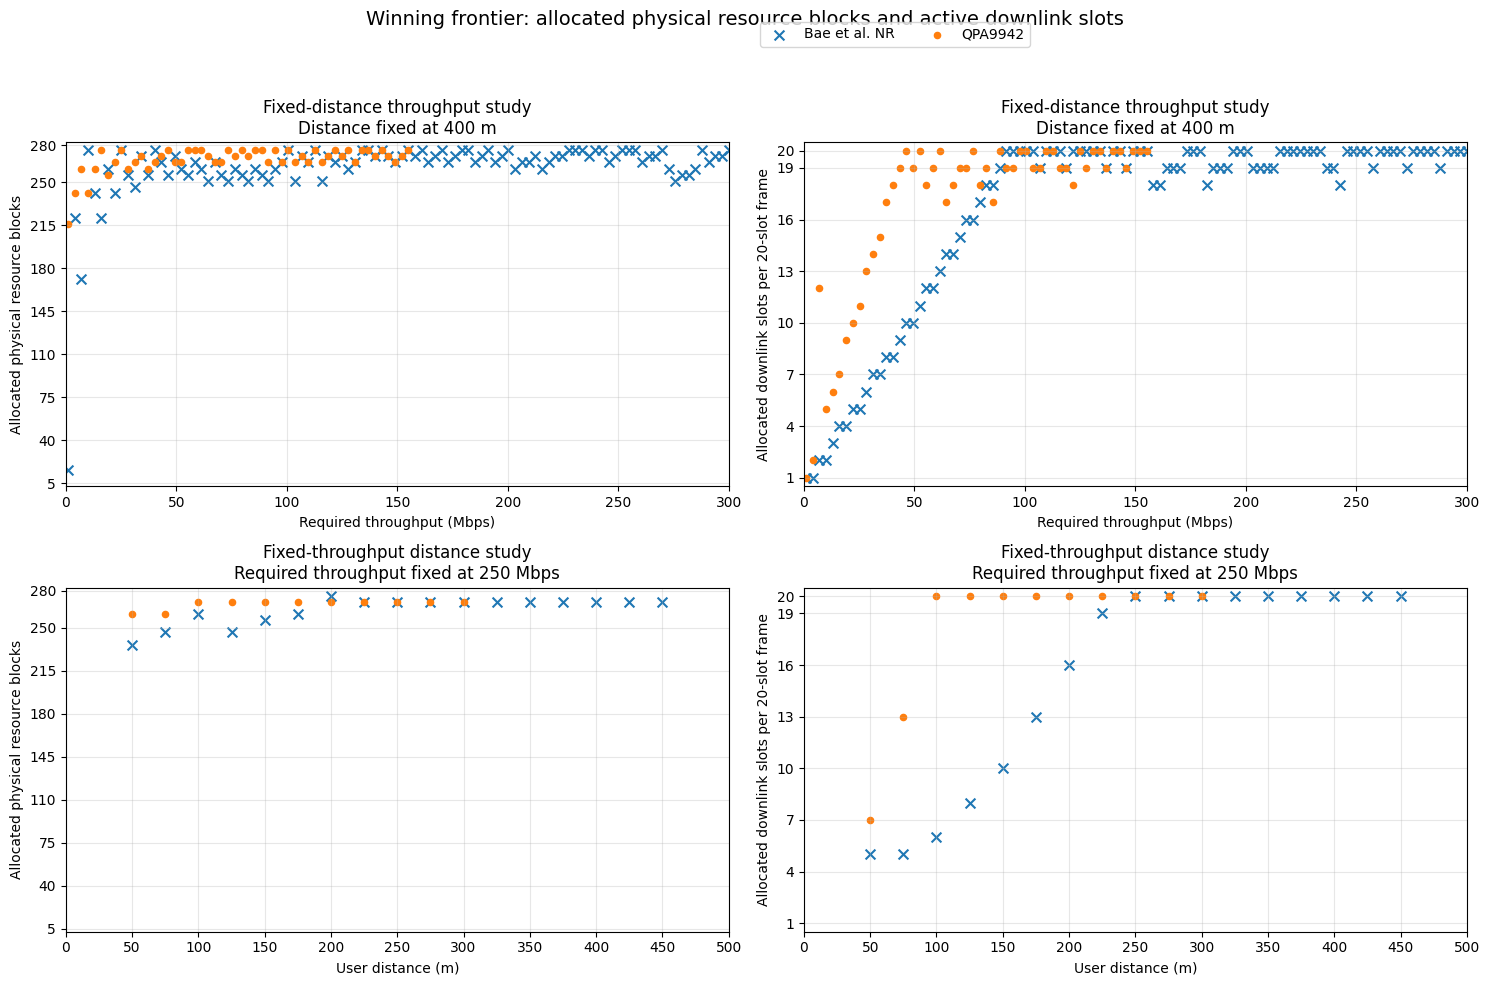

,scenario,at,winner PA,Allocated physical resource blocks,Allocated downlink slots per 20-slot frame
0,Fixed-distance throughput study,4.0 Mbps,QPA9942,241,2
1,Fixed-distance throughput study,7.0 Mbps,QPA9942,261,12
2,Fixed-distance throughput study,10.1 Mbps,QPA9942,241,5
3,Fixed-distance throughput study,13.1 Mbps,QPA9942,261,6
4,Fixed-distance throughput study,16.1 Mbps,QPA9942,276,7
5,Fixed-distance throughput study,19.1 Mbps,QPA9942,256,9
6,Fixed-throughput distance study,75 m,QPA9942,261,13
7,Fixed-throughput distance study,100 m,QPA9942,271,20


In [20]:
# Show how the winning frontier changes its PRB allocation and active-slot use.
fig_time_frequency = plot_grouped_frontier_figure(
    plot_context,
    metric_keys=["n_prb", "n_slots_on"],
    figure_title="Winning frontier: allocated physical resource blocks and active downlink slots",
)
time_frequency_summary = build_regime_summary(plot_context, ["n_prb", "n_slots_on"])
display(time_frequency_summary)


Again, the table marks regime boundaries rather than replacing the figure. It shows where the winner starts using more PRBs, more slots, or both, and makes the time-frequency duty-cycling logic visible in data as well as in prose.


### 6.4 Required SNR and PA energy per delivered bit

The last grouped figure closes the single-user interpretation. Required SNR shows the physical burden implied by the winning operating points, while PA energy per delivered bit adds a wider system-efficiency view than raw frame-averaged power alone.

This final pair should be read carefully. Required SNR helps explain why the optimiser must move toward costlier operating points, while energy per bit shows that minimising frame-averaged PA DC power is not the only useful way to compare configurations.


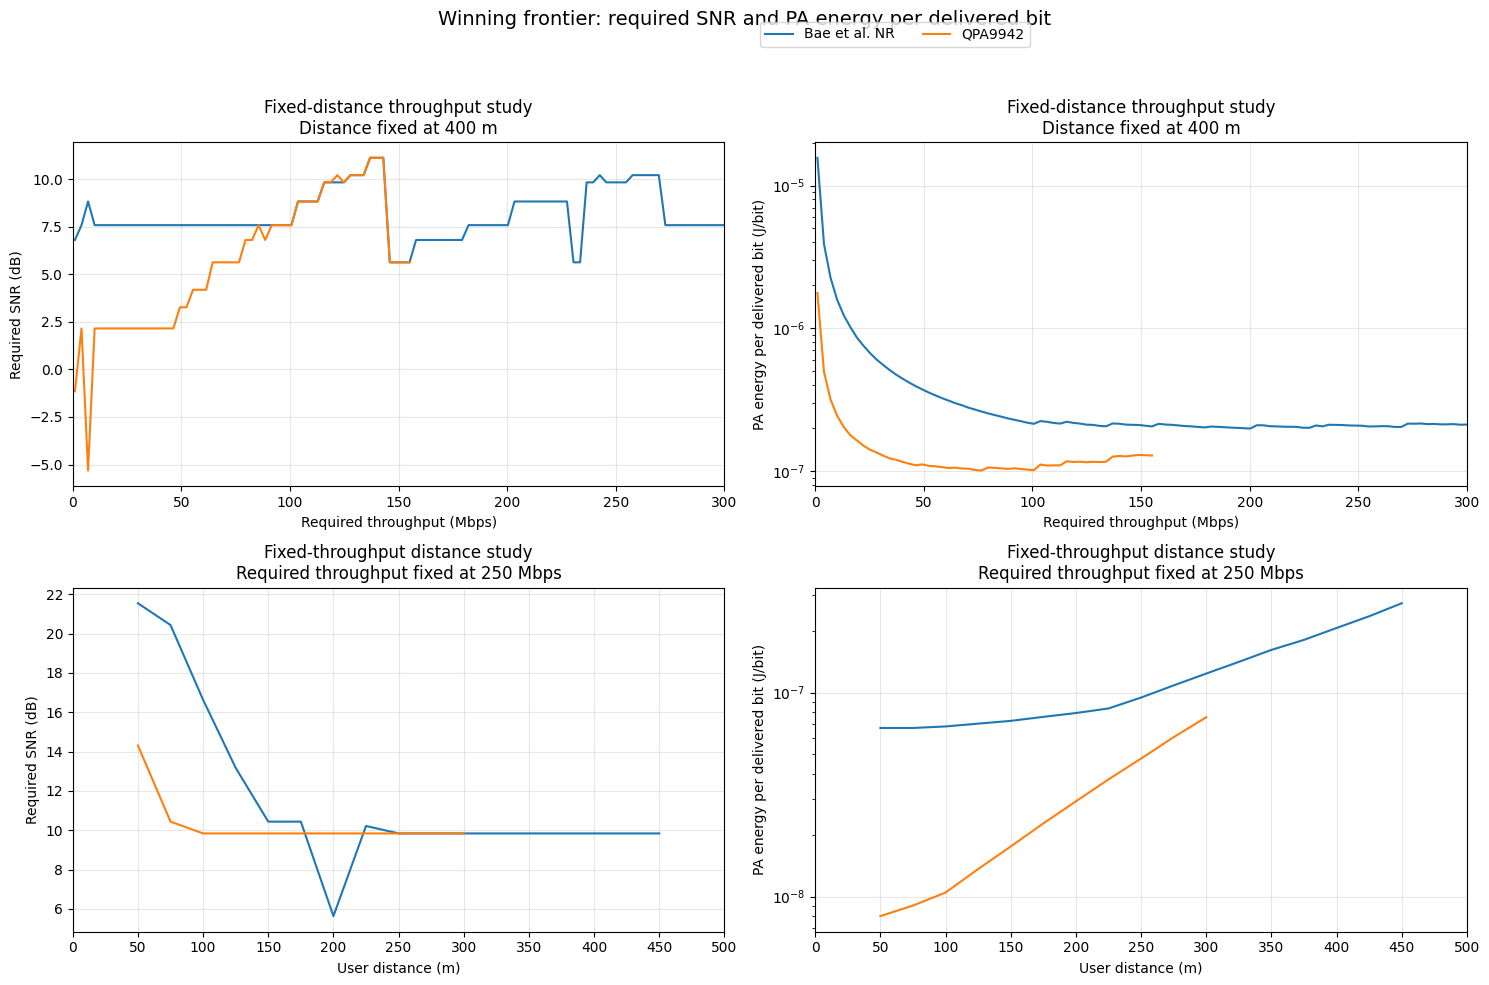

,scenario,minimum energy per bit,at minimum energy,PA at minimum energy,maximum required SNR (dB),at maximum required SNR
0,Fixed-distance throughput study,1.008729e-07,76.5 Mbps,QPA9942,11.127760,136.9 Mbps
1,Fixed-throughput distance study,8.016800e-09,50 m,QPA9942,14.306112,50 m


In [21]:
# Close the discussion with required SNR and PA energy per delivered bit.
fig_physical_energy = plot_grouped_frontier_figure(
    plot_context,
    metric_keys=["gamma_req_db", "energy_per_bit"],
    figure_title="Winning frontier: required SNR and PA energy per delivered bit",
)
physical_energy_summary = build_physical_energy_summary(plot_context)
display(physical_energy_summary)


The summary table identifies where the winning frontier reaches its lowest PA energy-per-bit point and where the required SNR becomes most severe. Together with the earlier figures, this closes the single-user story: the optimum depends on demand, on the PA choice, and on the resource-allocation choices available to the scheduler.


### 6.5 Bridge to multi-user scheduling

This single-user study has shown that there is no one static operating point that remains optimal in every case. The best configuration changes with required throughput, with distance, and with the structural choices the scheduler is allowed to make.

That is exactly why the next problem is harder. In a real system, many users must be scheduled at once, and each user can bring its own locally attractive operating points. The next step is therefore not to choose one single-user frontier row in isolation, but to coordinate many such rows under a shared multi-user TDMA resource budget.


## Appendix A. Export datasets

The main discussion ends above. The final cell is kept as an appendix utility that writes the main figures and the key tables to the repository output folders.

This keeps the notebook discussion readable while still making the study artefacts easy to reuse in the report or in later checks.


In [22]:
from pathlib import Path

required_objects = [
    "solver_interface_view",
    "reference_solver_summary_view",
    "fig_objective_vs_output",
    "fig_spatial_coding",
    "fig_time_frequency",
    "fig_physical_energy",
    "objective_output_summary",
    "spatial_coding_summary",
    "time_frequency_summary",
    "physical_energy_summary",
    "rate_frontier_table",
    "distance_frontier_table",
    "rate_explanatory_configs",
    "distance_explanatory_configs",
]
missing = [name for name in required_objects if name not in globals()]
assert not missing, f"Run the exploration and plot sections before saving outputs. Missing: {missing}"

graphs_dir = PROJECT_ROOT / "graphs"
csv_dir = PROJECT_ROOT / "csvs"
graphs_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

image_targets = {
    "frontier_objective_vs_output.png": fig_objective_vs_output,
    "frontier_spatial_coding.png": fig_spatial_coding,
    "frontier_time_frequency.png": fig_time_frequency,
    "frontier_physical_energy.png": fig_physical_energy,
}

for filename, fig in image_targets.items():
    fig.savefig(graphs_dir / filename, dpi=300, bbox_inches="tight")

table_targets = {
    "solver_interface_view.csv": solver_interface_view,
    "reference_solver_summary_view.csv": reference_solver_summary_view,
    "rate_frontier_by_pa.csv": rate_frontier_table,
    "distance_frontier_by_pa.csv": distance_frontier_table,
    "rate_explanatory_configs.csv": rate_explanatory_configs,
    "distance_explanatory_configs.csv": distance_explanatory_configs,
    "objective_output_summary.csv": objective_output_summary,
    "spatial_coding_summary.csv": spatial_coding_summary,
    "time_frequency_summary.csv": time_frequency_summary,
    "physical_energy_summary.csv": physical_energy_summary,
}

for filename, df in table_targets.items():
    df.to_csv(csv_dir / filename, index=False)

print(f"Saved {len(image_targets)} images to {graphs_dir.resolve()}")
print(f"Saved {len(table_targets)} tables to {csv_dir.resolve()}")


Saved 4 images to C:\Users\henry\Documents\Masters Thesis\code\graphs
Saved 10 tables to C:\Users\henry\Documents\Masters Thesis\code\csvs
